<a href="https://colab.research.google.com/github/abhishekjaiswal230430-rgb/ml/blob/main/Another_copy_of_4_Recurrent_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Part 1:  Recurrent Neural Network

In [1]:
!pip install numpy==1.16.2
import numpy as np
#Restart the kernel after running this code

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 29.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for numpy
  Running setup.py clean for numpy
  error: subprocess-exited-with-error
  
  × python setup.py clean did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed cleaning build dir for numpy
Failed to build numpy
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (numpy)


###  Importing packages

In [2]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.datasets import imdb

from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

### Preparing Dataset

Loads the IMDB movie reviews dataset - 50,000 reviews labeled as positive or negative sentiment

Keeps only the top 1,000 most frequent words - Reviews are now represented as sequences of numbers (word IDs from 1-1000)

Makes all reviews the same length (80 words):

Short reviews (<80 words) → Add zeros at the beginning

Long reviews (>80 words) → Cut off words after position 80

x_train[0] = [12, 45, 3, 789, 23, 1, 456]  (review text as numbers)
y_train[0] = 1                               (positive sentiment)

x_test[0] = [67, 234, 8, 99, 4]            (different review)
y_test[0] = 0                               (negative sentiment)

In [3]:

max_features = 1000
maxlen = 80  # cut texts after this number of words (among top max_features most common words)
batch_size = 32

print('Loading data...')
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

print('Pad sequences (samples x time)')
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 80)
x_test shape: (25000, 80)


In [4]:
y_train[0]

np.int64(1)

### Visualize the data

In [5]:
INDEX_FROM=3   # word index offset

word_to_id = imdb.get_word_index()
word_to_id = {k:(v+INDEX_FROM) for k,v in word_to_id.items()}
word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2

id_to_word = {value:key for key,value in word_to_id.items()}
print(' '.join(id_to_word[id] for id in x_train[0] ))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
that played the <UNK> of <UNK> and paul they were just brilliant children are often left out of the <UNK> <UNK> i think because the stars that play them all <UNK> up are such a big <UNK> for the whole film but these children are amazing and should be <UNK> for what they have done don't you think the whole story was so <UNK> because it was true and was <UNK> life after all that was <UNK> with us all


Simple formula for LSTM Parameters -  4 × (units × (units + input_dim) + units)

### Building a Model

In [6]:
model = Sequential()
model.add(Embedding(max_features, 8))
model.add(LSTM(16, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.build(input_shape=(None, maxlen))  # ← Build with input shape
model.summary()  # Now shows real numbers!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 8)          │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,617 (37.57 KB)

 Trainable params: 9,617 (37.57 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [7]:
# try using different optimizers and different optimizer configs
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Write the training input and output, batch size, and testing input and output

model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=1,
          validation_data=(x_test, y_test))

782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 81ms/step - accuracy: 0.7066 - loss: 0.5595 - val_accuracy: 0.8019 - val_loss: 0.4313


### Testing

In [8]:
score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8019 - loss: 0.4313
Test score: 0.43126776814460754
Test accuracy: 0.8019199967384338


### Prediction

In [9]:
# ADD THIS LINE - Shows the review
print('Review:', ' '.join([id_to_word[id] for id in x_test[2] if id > 2]))

# YOUR ORIGINAL CODE
prediction = model.predict(x_test[2:3])
print('Prediction value:', prediction[0])
print('Test Label:', y_test[2:3])

Review: events may or may not have had in mind when he made but whatever his of material the film as a tale of could be the or in the or any country of any era that its down and is by it's a film even a one in its way but its message is no joke
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Prediction value: [0.17661376]
Test Label: [1]


### Other RNN Layers

* keras.layers.RNN(cell, return_sequences=False)
* keras.layers.SimpleRNN(units, activation='tanh')
* keras.layers.GRU(units, activation='tanh', recurrent_activation='hard_sigmoid')
* keras.layers.ConvLSTM2D(filters, kernel_size, strides=(1, 1), padding='valid', )
* keras.layers.SimpleRNNCell(units, activation='tanh')
* keras.layers.GRUCell(units, activation='tanh', recurrent_activation='hard_sigmoid')
* keras.layers.LSTMCell(units, activation='tanh', recurrent_activation='hard_sigmoid')
* keras.layers.CuDNNGRU(units, kernel_initializer='glorot_uniform')
* keras.layers.CuDNNLSTM(units, kernel_initializer='glorot_uniform')

# Part 2: Recurrent Neural Network with Custom Dataset

In [10]:
# Credits to Peter Nagy

### Load data

### Upload `Senti.csv`

Please upload the `Senti.csv` file to your Colab environment. You can do this by clicking the folder icon on the left sidebar, then the upload icon (an arrow pointing up), and selecting 'Senti.csv' from your local machine.

If you don't have the file or want to proceed with a sample dataset, you can run the following cell to create a dummy `Senti.csv`.

In [14]:
import pandas as pd
import os

# Check if 'Senti.csv' exists, if not, create a dummy one
if not os.path.exists('Senti.csv'):
    print("Senti.csv not found, creating a dummy file...")
    dummy_data = {
        'text': [
            'I love this movie, it is fantastic!',
            'This is the worst film ever, a complete waste of time.',
            'It was okay, nothing special.',
            'Absolutely brilliant, highly recommend it.',
            'Terrible acting and boring plot.',
            'So good, I watched it twice!',
            'Not great, not terrible.'
        ],
        'sentiment': [
            'Positive',
            'Negative',
            'Neutral',
            'Positive',
            'Negative',
            'Positive',
            'Neutral'
        ]
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv('Senti.csv', index=False)
    print("Dummy 'Senti.csv' created.")
else:
    print("Senti.csv already exists.")

Senti.csv not found, creating a dummy file...
Dummy 'Senti.csv' created.


In [16]:
data = pd.read_csv('/content/Senti.csv')
# Keeping only the neccessary columns
data = data[['text','sentiment']]

Sentiment Distribution:
sentiment
Positive    60.0
Negative    40.0
Name: count, dtype: float64


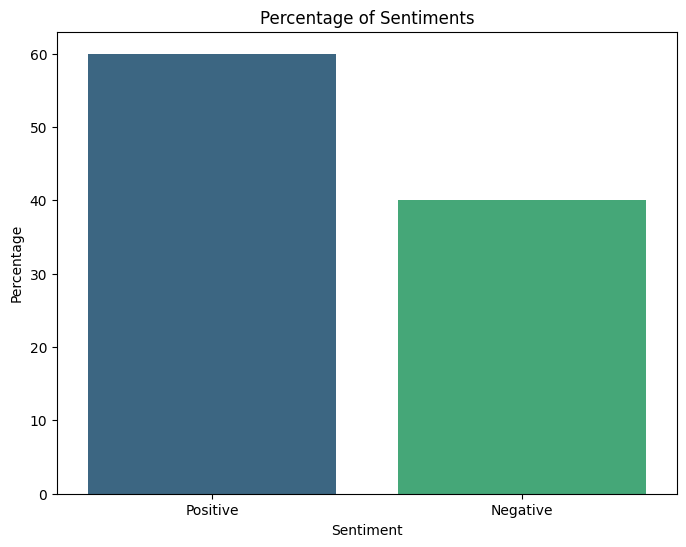

In [34]:
# Calculate the percentage of each sentiment
sentiment_counts = data['sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(data)) * 100

print("Sentiment Distribution:")
print(sentiment_percentages)

# Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_percentages.index, y=sentiment_percentages.values, palette='viridis')
plt.title('Percentage of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.show()

In [17]:
display(data.head())

,text,sentiment
0,"I love this movie, it is fantastic!",Positive
1,"This is the worst film ever, a complete waste ...",Negative
2,"It was okay, nothing special.",Neutral
3,"Absolutely brilliant, highly recommend it.",Positive
4,Terrible acting and boring plot.,Negative


### Visualize data

In [18]:
data.head(10)

,text,sentiment
0,"I love this movie, it is fantastic!",Positive
1,"This is the worst film ever, a complete waste ...",Negative
2,"It was okay, nothing special.",Neutral
3,"Absolutely brilliant, highly recommend it.",Positive
4,Terrible acting and boring plot.,Negative
5,"So good, I watched it twice!",Positive
6,"Not great, not terrible.",Neutral


### Format data

In [19]:
data = data[data.sentiment != "Neutral"]
data['text'] = data['text'].apply(lambda x: x.lower())
data['text'] = data['text'].apply((lambda x: re.sub('[^a-zA-z0-9\s]','',x)))

for idx,row in data.iterrows():
    row[0] = row[0].replace('rt',' ')

max_fatures = 2000
tokenizer = Tokenizer(nb_words=max_fatures, split=' ')
tokenizer.fit_on_texts(data['text'].values)
X = tokenizer.texts_to_sequences(data['text'].values)
X = pad_sequences(X)

### Training set

In [20]:
Y = pd.get_dummies(data['sentiment']).values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.33, random_state = 42)
print('Shape of training samples:',X_train.shape,Y_train.shape)
print('Shape of testing samples:',X_test.shape,Y_test.shape)

Shape of training samples: (3, 11) (3, 2)
Shape of testing samples: (2, 11) (2, 2)


### Design a model

In [23]:
model = Sequential()
model.add(Embedding(max_fatures, 128 ,input_length = X.shape[1]))
model.add(LSTM(128))
model.add(Dense(2, activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer='adam',metrics = ['accuracy'])
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Training

In [24]:
batch_size = 32
model.fit(X_train, Y_train, epochs = 5, batch_size=batch_size, verbose = 2)

Epoch 1/5
1/1 - 2s - 2s/step - accuracy: 0.0000e+00 - loss: 0.6998
Epoch 2/5
1/1 - 0s - 61ms/step - accuracy: 0.6667 - loss: 0.6798
Epoch 3/5
1/1 - 0s - 58ms/step - accuracy: 0.6667 - loss: 0.6602
Epoch 4/5
1/1 - 0s - 62ms/step - accuracy: 0.6667 - loss: 0.6400
Epoch 5/5
1/1 - 0s - 61ms/step - accuracy: 0.6667 - loss: 0.6185


### Validation

In [25]:
score,acc = model.evaluate(X_test, Y_test, verbose = 2, batch_size = batch_size)
print("Score: %.2f" % (score))
print("Accuracy: %.2f" % (acc))

1/1 - 0s - 364ms/step - accuracy: 0.5000 - loss: 0.6521
Score: 0.65
Accuracy: 0.50


### Formatting Test Example

In [26]:
text = 'I like him'
tester = np.array([text])
tester = pd.DataFrame(tester)
tester.columns = ['text']

tester['text'] = tester['text'].apply(lambda x: x.lower())
tester['text'] = tester['text'].apply((lambda x: re.sub('[^a-zA-z0-9\s]','',x)))

max_fatures = 2000
test = tokenizer.texts_to_sequences(tester['text'].values)
test = pad_sequences(test)

if X.shape[1]>test.shape[1]:
    test = np.pad(test[0], (X.shape[1]-test.shape[1],0), 'constant')

test = np.array([test])

prediction = model.predict(test)
print('Prediction value:',prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Prediction value: [0.40918377 0.5908162 ]


# Part 3: RNN Design Choices

## Influence of number of nodes

### LSTM with 8 nodes

Simple formula for LSTM Parameters -  4 × (units × (units + input_dim) + units)

In [27]:
model = Sequential()
model.add(Embedding(max_features, 8))
model.add(LSTM(8, dropout=0.0, recurrent_dropout=0.0))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=1, validation_data=(x_test, y_test))

score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.7318 - loss: 0.5138 - val_accuracy: 0.8099 - val_loss: 0.4145
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8099 - loss: 0.4145
Test score: 0.41446980834007263
Test accuracy: 0.8099200129508972


### LSTM with 16 nodes

In [28]:
# Write your code here

# Use the same layer design from the above cell

## Influence of Embedding

In [29]:
model = Sequential()
model.add(Embedding(max_features, 4))
model.add(LSTM(16, dropout=0.0, recurrent_dropout=0.0))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=1, validation_data=(x_test, y_test))

score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.7339 - loss: 0.5173 - val_accuracy: 0.8137 - val_loss: 0.4073
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8137 - loss: 0.4073
Test score: 0.40729254484176636
Test accuracy: 0.8137199878692627


## Influence of Dropout

### Dropout with probability 0.5

In [30]:
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(LSTM(8, dropout=0.5, recurrent_dropout=0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=1, validation_data=(x_test, y_test))

score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.6748 - loss: 0.5992 - val_accuracy: 0.7519 - val_loss: 0.5075
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7519 - loss: 0.5075
Test score: 0.5075021386146545
Test accuracy: 0.7519199848175049


### Dropout with probability 0.9

In [31]:
# Write your code here

# Use the same model design from the above cell

## Multilayered RNNs

### RNN with 2 layer LSTM

In [32]:
model = Sequential()
model.add(Embedding(max_features, 8))
model.add(LSTM(8, dropout=0.0, recurrent_dropout=0.0, return_sequences=True))
model.add(LSTM(8, dropout=0.0, recurrent_dropout=0.0))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=1, validation_data=(x_test, y_test))

score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.7446 - loss: 0.5015 - val_accuracy: 0.7729 - val_loss: 0.4639
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7729 - loss: 0.4639
Test score: 0.4638967514038086
Test accuracy: 0.7728800177574158


### RNN with 3 layer LSTM

In [33]:
# Write your code here

# Use the same node design from the above cell

### What are your findings?